In [7]:
# ================================================
# DAY 5 — Matplotlib Data Visualisation
# Phetho Tlaka | April 2026
# ================================================
# We import 3 libraries:
# pandas — to load and clean data
# numpy — for number operations
# matplotlib.pyplot — for creating charts
# pyplot is the part of matplotlib we use most
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file — same as Day 4
df = pd.read_csv('titanic.csv')

# Always work on a copy — never destroy original
df_clean = df.copy()

# Drop Cabin — 77% missing, not useful
df_clean = df_clean.drop(columns=['Cabin'])

# Fill missing Age with median age
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Fill missing Embarked with most common port (S)
df_clean['Embarked'] = df_clean['Embarked'].fillna('S')

# Make Sex lowercase for consistency
df_clean['Sex'] = df_clean['Sex'].str.lower()

# Add a readable label column — 0=Died, 1=Survived
df_clean['Survived_label'] = df_clean['Survived'].map({0: 'Died', 1: 'Survived'})

# pd.cut() groups continuous ages into categories
# bins = the boundaries: 0-12, 12-18, 18-35, 35-60, 60-100
# labels = the name for each group
df_clean['Age_group'] = pd.cut(df_clean['Age'], bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior'])

print("Data loaded and cleaned!")
print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print("Ready to visualise!")

Data loaded and cleaned!
Shape: (891, 13)
Missing values: 0
Ready to visualise!


Survival rates by gender:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64



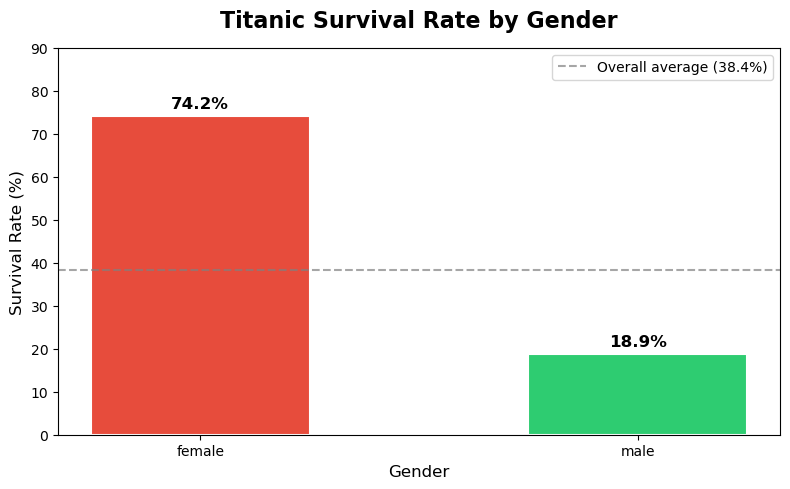

Chart 1 saved!


In [8]:
# ================================================
# CHART 1: SURVIVAL BY GENDER
# ================================================
# groupby('Sex') splits data into female and male groups
# ['Survived'].mean() calculates average survival per group
# * 100 converts decimal (0.74) to percentage (74.2)
gender_survival = df_clean.groupby('Sex')['Survived'].mean() * 100

print("Survival rates by gender:")
print(gender_survival.round(1))
print()

# plt.figure() creates a blank canvas to draw on
# figsize=(8, 5) = 8 inches wide, 5 inches tall
plt.figure(figsize=(8, 5))

# Colors for each bar — red for female, green for male
# These are HEX color codes — same as in HTML/CSS
colors = ['#E74C3C', '#2ECC71']

# plt.bar() draws the bars
# gender_survival.index = x axis labels (female, male)
# gender_survival.values = the height of each bar
bars = plt.bar(
    gender_survival.index,
    gender_survival.values,
    color=colors,
    width=0.5,          # how wide each bar is
    edgecolor='white',  # white border around bars
    linewidth=1.5       # thickness of the border
)

# Loop through each bar and add a percentage label on top
# zip() lets us loop through bars and values at the same time
for bar, value in zip(bars, gender_survival.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position = centre of bar
        bar.get_height() + 1,               # y position = just above bar
        f'{value:.1f}%',                    # the text to display
        ha='center',                        # horizontal alignment
        va='bottom',                        # vertical alignment
        fontsize=12,
        fontweight='bold'
    )

# Chart title and axis labels
plt.title('Titanic Survival Rate by Gender', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

# ylim sets the y axis range — 0 to 90%
plt.ylim(0, 90)

# axhline draws a horizontal reference line
# y=38.4 = the overall average survival rate
# linestyle='--' = dashed line
# alpha=0.7 = slightly transparent
plt.axhline(y=38.4, color='gray', linestyle='--', alpha=0.7, label='Overall average (38.4%)')

plt.legend()        # shows the legend box
plt.tight_layout()  # auto-adjusts spacing so nothing overlaps

# Save the chart as a PNG image file
# dpi=150 = high quality image
# bbox_inches='tight' = no whitespace around edges
plt.savefig('chart1_gender_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

Survival rates by class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64



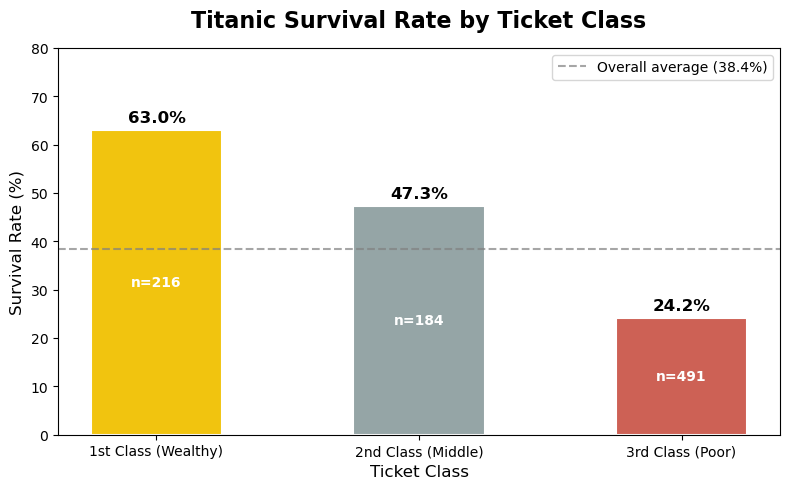

Chart 2 saved!


In [9]:
# ================================================
# CHART 2: SURVIVAL BY TICKET CLASS
# ================================================
# This shows how wealth affected survival chances
# 1st class = wealthy, 3rd class = poor/immigrants

# Calculate survival rate per class (1, 2, 3)
class_survival = df_clean.groupby('Pclass')['Survived'].mean() * 100

# Also count how many passengers were in each class
# We will display this inside each bar
class_counts = df_clean.groupby('Pclass')['Survived'].count()

print("Survival rates by class:")
print(class_survival.round(1))
print()

# Human readable labels — replaces 1, 2, 3 with full names
class_labels = ['1st Class (Wealthy)', '2nd Class (Middle)', '3rd Class (Poor)']

# Gold for 1st class, grey for 2nd, red for 3rd
colors = ['#F1C40F', '#95A5A6', '#CD6155']

plt.figure(figsize=(8, 5))
bars = plt.bar(class_labels, class_survival.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# zip() with 3 lists — loops through bar, value, and count together
for bar, value, count in zip(bars, class_survival.values, class_counts.values):

    # Label 1: survival percentage — shown ABOVE the bar
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Label 2: passenger count — shown INSIDE the bar
    # bar.get_height() / 2 = middle of the bar
    # color='white' so it is visible against the coloured bar
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'n={count}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.title('Titanic Survival Rate by Ticket Class', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ticket Class', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.ylim(0, 80)
plt.axhline(y=38.4, color='gray', linestyle='--', alpha=0.7, label='Overall average (38.4%)')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_class_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

Survived: 342
Died:     549



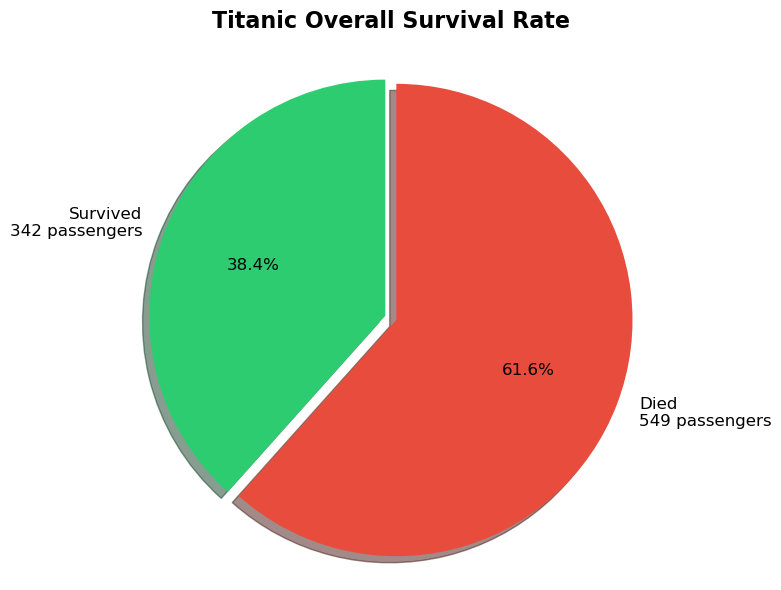

Chart 3 saved!


In [10]:
# ================================================
# CHART 3: OVERALL SURVIVAL — PIE CHART
# ================================================
# A pie chart shows proportions of a whole
# Perfect for showing survived vs died split
# Each slice = one category
# The size of the slice = the percentage

# Count how many survived and died
survived_count = df_clean['Survived'].sum()        # sum of 1s = total survived
died_count = len(df_clean) - survived_count        # total minus survived = died

print(f"Survived: {survived_count}")
print(f"Died:     {died_count}")
print()

# The values for each slice
sizes = [survived_count, died_count]

# Label for each slice
labels = [f'Survived\n{survived_count} passengers',
          f'Died\n{died_count} passengers']

# Colors — green for survived, red for died
colors = ['#2ECC71', '#E74C3C']

# explode = pulls a slice out slightly to highlight it
# 0.05 = pull survived slice out by 5%
# 0 = died slice stays in place
explode = (0.05, 0)

plt.figure(figsize=(8, 6))

# plt.pie() draws the pie chart
# autopct='%1.1f%%' adds percentage labels on each slice
# startangle=90 rotates chart so it starts from top
# shadow=True adds a subtle shadow effect
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',    # format: 38.4%
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)

plt.title('Titanic Overall Survival Rate',
          fontsize=16, fontweight='bold', pad=20)

# equal makes sure the pie is a circle not oval
plt.axis('equal')

plt.tight_layout()
plt.savefig('chart3_overall_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")